# 04 · models — xgboost + catboost on the Untitled.ipynb feature blueprint

everything upstream is now unified: notebook 02's label (median benchmark, delisted-inclusive,
leak-checked) and notebook 03's 49-feature store (technical + peer-relative v2 + `feature_eng.py`'s
additions + leave-one-out benchmark variants + volume). the model trained and walk-forwarded here
uses the **Untitled.ipynb 9-feature blueprint** (`beta_60d, cat_n, peer_rank_20d, cs_rank_ret_5d,
ret_20d_skip5, vol_20d` + 3 volume features) by explicit choice — section 1's ablation runs a wider
comparison for context, but does not override that choice. CatBoost uses the hyperparameters already
found by grid search (`catboost_grid_results.csv` / `1catboost_grid_results.csv`) rather than
re-searching.

run 01-03 first. supersedes `04_baseline.ipynb` (the mean-benchmark bug) and `06_features_v2.ipynb`
(feature catalogue absorbed into 03) — both archived, not deleted. `Untitled.ipynb`'s modeling
approach is carried forward here rather than superseded.

In [1]:
import yaml, pathlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200, 'display.max_columns', 40)

ROOT = pathlib.Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
import common
cfg = yaml.safe_load(open(ROOT / 'config.yaml', encoding='utf-8'))
RAW, PROC = ROOT / cfg['paths']['raw'], ROOT / cfg['paths']['processed']
H = cfg['labels']['horizon']

prices = pd.read_parquet(RAW / 'prices.parquet')       # only used for its trading-day DatetimeIndex
prices.index.name = 'date'; prices.columns.name = 'ticker'
metadata = pd.read_parquet(RAW / 'metadata.parquet')
grp = metadata['category_group']

features = pd.read_parquet(PROC / 'features.parquet')
labels = pd.read_parquet(PROC / 'labels.parquet')
data = features.join(labels[['label']], how='inner').dropna()
data['label'] = data['label'].astype(int)
d = data.reset_index()
print('modeling dataset:', data.shape, '|', d['date'].min().date(), '->', d['date'].max().date())
print('label balance:', d['label'].value_counts(normalize=True).round(3).to_dict())

modeling dataset: (3249014, 50) | 2016-10-11 -> 2026-07-02
label balance: {2: 0.341, 1: 0.333, 0: 0.326}


## model helpers

both models share `common.py`'s `walk_forward`/`purge_cutoff` — the only thing that differs between
them is `fit_fn(train_df, cols) -> fitted model`, so purge/scoring logic can't drift between the two
the way it once did between notebooks.

In [2]:
def _check_cuda_xgb():
    try:
        import xgboost as xgb
        dm = xgb.DMatrix([[1, 2], [3, 4]], label=[0, 1])
        xgb.train({'tree_method': 'hist', 'device': 'cuda', 'objective': 'binary:logistic'},
                  dm, num_boost_round=1, verbose_eval=False)
        return True
    except Exception:
        return False

USE_CUDA_XGB = _check_cuda_xgb()
print('CUDA available for XGBoost:', USE_CUDA_XGB)

def make_xgb(overrides=None):
    params = dict(objective='multi:softprob', num_class=3,
                  n_estimators=250, max_depth=4, learning_rate=0.1,
                  subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                  n_jobs=-1, eval_metric='mlogloss', random_state=0)
    if overrides:
        params.update(overrides)
    if USE_CUDA_XGB:
        params['device'] = 'cuda'; params.pop('n_jobs', None)
    return XGBClassifier(**params)

def fit_xgb(train, cols, overrides=None):
    return make_xgb(overrides).fit(train[cols], train['label'])

def fit_eval_xgb(train, test, cols, overrides=None):
    """Single-split convenience wrapper for the ablation below (walk_forward handles the
    multi-year case)."""
    mdl = fit_xgb(train, cols, overrides)
    p = common.predict_labels(mdl, test[cols])
    return mdl, p, accuracy_score(test['label'], p), f1_score(test['label'], p, average='macro')

CUDA available for XGBoost: True


In [3]:
def _check_cuda_cb():
    try:
        from catboost.utils import get_gpu_device_count
        return get_gpu_device_count() > 0
    except Exception:
        return False

USE_CUDA_CB = _check_cuda_cb()
print('CUDA available for CatBoost:', USE_CUDA_CB)

# best config found by the grid search already run (Untitled.ipynb -> catboost_grid_results.csv +
# 1catboost_grid_results.csv: two sequential sweeps, not duplicates -- a broad one over
# depth x lr x l2 x random_strength x bagging_temperature, then a refined one over depth x lr once
# the broad sweep narrowed the useful range). best by mean_macro_f1 across both: depth=7, lr=0.04,
# l2_leaf_reg=3 (macro-F1 0.417, accuracy 0.421). class_weights from the earlier weight sweep.
CB_BEST_PARAMS = dict(loss_function='MultiClass', eval_metric='TotalF1:average=Macro',
                      iterations=2000, learning_rate=0.04, depth=7, l2_leaf_reg=3, random_seed=0)
CB_BEST_WEIGHTS = [1.25, 1.0, 1.25]

def make_catboost(overrides=None, weights=CB_BEST_WEIGHTS):
    params = dict(CB_BEST_PARAMS)
    if overrides:
        params.update(overrides)
    if USE_CUDA_CB:
        params['task_type'] = 'GPU'; params['devices'] = '0'
    return CatBoostClassifier(**params, class_weights=weights, verbose=False)

def fit_catboost(train, cols, overrides=None, weights=CB_BEST_WEIGHTS):
    """Carves an internal 95/5 (by date) validation tail for early stopping -- matches
    Untitled.ipynb's approach."""
    train = train.sort_values('date')
    dates = np.sort(train['date'].unique())
    val_start = dates[int(len(dates) * 0.95)]
    fit_tr, fit_val = train[train['date'] < val_start], train[train['date'] >= val_start]
    model = make_catboost(overrides, weights)
    model.fit(fit_tr[cols], fit_tr['label'], eval_set=(fit_val[cols], fit_val['label']),
              early_stopping_rounds=50, use_best_model=True, verbose=False)
    return model

def fit_eval_catboost(train, test, cols, overrides=None, weights=CB_BEST_WEIGHTS):
    mdl = fit_catboost(train, cols, overrides, weights)
    p = common.predict_labels(mdl, test[cols])
    return mdl, p, accuracy_score(test['label'], p), f1_score(test['label'], p, average='macro')

CUDA available for CatBoost: True


## 1) one unified ablation — resolves the open questions from notebook 03

single 2023-12-31 split (purged, apples-to-apples with the historical baseline), XGBoost, cumulative
feature groups **plus** four targeted comparisons that were left as open questions rather than
guesses:

- **`peer_rank_20d`**: nb05 kept it out of modeling ("shares the ranking mechanism with the label");
  `Untitled.ipynb` used it as a top feature anyway. `D + peer_rank_20d` vs `D full` settles it.
- **`vol_20d_raw`**: `feature_eng.py`'s unannualized vol definition vs the existing annualized one.
- **volume**: does `Untitled.ipynb`'s own conclusion (small genuine lift from `cs_rank_dollar_vol`)
  hold up against the full 36-feature base, not just its own 6-feature core?
- **`beta_60d` vs `beta_60d_xself`**: does the leave-one-out category benchmark (no mechanical
  self-correlation) actually change anything once it's swapped into the full feature set?

In [ ]:
D36_XSELF = [c if c != 'beta_60d' else 'beta_60d_xself' for c in common.D36]
UNTITLED_BLUEPRINT = ['beta_60d', 'cat_n', 'peer_rank_20d', 'cs_rank_ret_5d', 'ret_20d_skip5', 'vol_20d'] + common.VOL

ABLATION_SETS = [
    ('A crude (3)', ['ret_5d', 'vol_20d', 'rel_str_5d']),
    ('B technical (17)', common.TECH),
    ('C tech+friend (20)', common.TECH + common.FRIEND),
    ('C + position (24)', common.TECH + common.FRIEND + common.POS),
    ('C + alpha (27)', common.TECH + common.FRIEND + common.ALPHA),
    ('C + context (25)', common.TECH + common.FRIEND + common.CTX),
    ('D full (36)', common.D36),
    ('D + peer_rank_20d (37)', common.D36 + ['peer_rank_20d']),
    ('D + vol_20d_raw (37)', common.D36 + ['vol_20d_raw']),
    ('D + volume (39)', common.D36 + common.VOL),
    ('D, beta xself (36)', D36_XSELF),
    ('ALL (49)', common.FEATURE_COLS),
    ('Untitled.ipynb blueprint (9)', UNTITLED_BLUEPRINT),
]

split = pd.Timestamp(cfg['split']['date'])
te_s = d[d['date'] > split]
first_test = te_s['date'].min()
cut = common.purge_cutoff(prices.index, first_test, H)
tr_s = d[d['date'] <= cut]

rows, ablation_models = [], {}
for name, cols in ABLATION_SETS:
    mdl, p, acc, mf1 = fit_eval_xgb(tr_s, te_s, cols)
    ablation_models[name] = (mdl, cols, p)
    rows.append({'feature_set': name, 'n_feat': len(cols), 'accuracy': round(acc, 3), 'macro_F1': round(mf1, 3)})
lift = pd.DataFrame(rows)
lift['acc_vs_random'] = (lift['accuracy'] - 1 / 3).round(3)
print(f'purge cutoff {cut.date()} (nominal split {split.date()}) | train {len(tr_s):,} rows, test {len(te_s):,} rows')
print(lift.to_string(index=False))

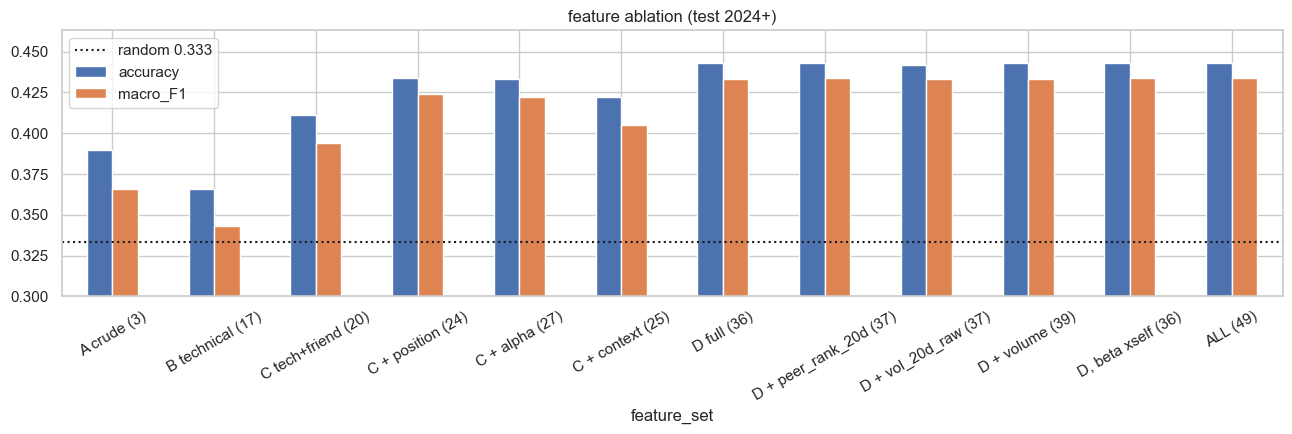

peer_rank_20d added to D full : +0.000 accuracy
volume added to D full        : +0.000 accuracy
vol_20d_raw added to D full   : -0.001 accuracy
beta_60d -> beta_60d_xself    : +0.000 accuracy  (swap, same feature count)


In [5]:
ax = lift.set_index('feature_set')[['accuracy', 'macro_F1']].plot.bar(figsize=(13, 4.5))
ax.axhline(1 / 3, color='k', ls=':', label='random 0.333'); ax.set_ylim(0.30, max(0.45, lift['accuracy'].max() + 0.02))
ax.set_title('feature ablation (test 2024+)'); ax.legend(); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

peer_lift = lift.set_index('feature_set').loc['D + peer_rank_20d (37)', 'accuracy'] - lift.set_index('feature_set').loc['D full (36)', 'accuracy']
vol_lift = lift.set_index('feature_set').loc['D + volume (39)', 'accuracy'] - lift.set_index('feature_set').loc['D full (36)', 'accuracy']
xself_lift = lift.set_index('feature_set').loc['D, beta xself (36)', 'accuracy'] - lift.set_index('feature_set').loc['D full (36)', 'accuracy']
raw_lift = lift.set_index('feature_set').loc['D + vol_20d_raw (37)', 'accuracy'] - lift.set_index('feature_set').loc['D full (36)', 'accuracy']
print(f'peer_rank_20d added to D full : {peer_lift:+.3f} accuracy')
print(f'volume added to D full        : {vol_lift:+.3f} accuracy')
print(f'vol_20d_raw added to D full   : {raw_lift:+.3f} accuracy')
print(f'beta_60d -> beta_60d_xself    : {xself_lift:+.3f} accuracy  (swap, same feature count)')

## 2) walk-forward, purged — XGBoost on the Untitled.ipynb feature blueprint

**feature set is fixed to `UNTITLED_BLUEPRINT` (9 features) by request, not picked by the ablation
above** — the ablation table still shows how it compares to the other groups for context, but the
model trained and evaluated from here on uses exactly `beta_60d, cat_n, peer_rank_20d,
cs_rank_ret_5d, ret_20d_skip5, vol_20d` + the 3 volume features, matching `Untitled.ipynb`'s
original blueprint.

expanding window: train on everything up to the last trading day whose forward-5d label window ends
on/before the test year's first trading day (`common.purge_cutoff`, trading days not calendar days),
test that year. also re-scored on a non-overlapping subset (every 5th trading day) as a check against
within-test label overlap (autocorr ~0.76, per notebook 02).

In [ ]:
best_name = 'Untitled.ipynb blueprint (9)'
best_cols = UNTITLED_BLUEPRINT
print(f'feature set used for walk-forward + final models: {best_name}  ({len(best_cols)} features)')
print(f'columns: {best_cols}')

WF_START, WF_END = cfg['model']['walkforward_start'], int(d['date'].dt.year.max())
wf_xgb, oof_xgb, _ = common.walk_forward(d, best_cols, fit_xgb, range(WF_START, WF_END + 1), H, prices.index)
print(wf_xgb.to_string(index=False))
print(f'\nwalk-forward mean (full test)   : accuracy {wf_xgb["accuracy"].mean():.3f}  macro-F1 {wf_xgb["macro_f1"].mean():.3f}  (random 0.333)')
print(f'walk-forward mean (non-overlap) : accuracy {wf_xgb["acc_nonoverlap"].mean():.3f}  macro-F1 {wf_xgb["mf1_nonoverlap"].mean():.3f}')
gap = abs(wf_xgb['accuracy'].mean() - wf_xgb['acc_nonoverlap'].mean())
print(f'gap                              : {gap:.3f} accuracy points',
      '- MATERIAL, see verdict' if gap > 0.02 else '- consistent, overlap is not distorting the headline number')

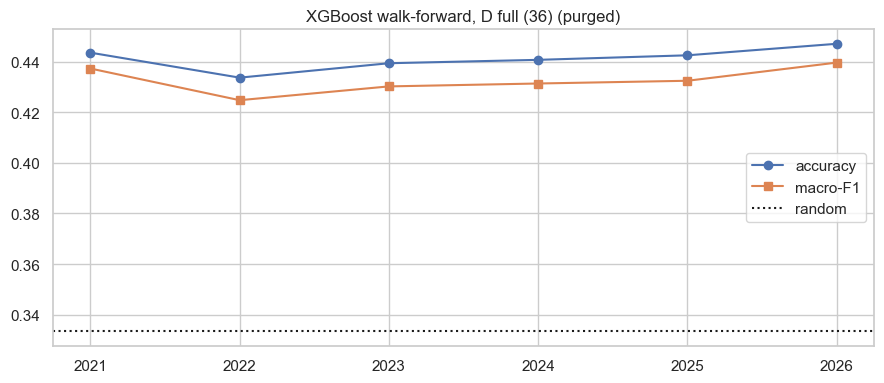

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(wf_xgb['test_year'], wf_xgb['accuracy'], marker='o', label='accuracy')
ax.plot(wf_xgb['test_year'], wf_xgb['macro_f1'], marker='s', label='macro-F1')
ax.axhline(1 / 3, color='k', ls=':', label='random'); ax.set_title(f'XGBoost walk-forward, {best_name} (purged)'); ax.legend()
plt.tight_layout(); plt.show()

### the winning model — confusion, per-group, importance

single-split (D full (36)): accuracy 0.443 (vs 0.333)   macro-F1 0.433


              precision    recall  f1-score   support

       Under      0.416     0.316     0.359    271593
     Neutral      0.484     0.632     0.548    278982
         Out      0.406     0.377     0.391    284569

    accuracy                          0.443    835144
   macro avg      0.436     0.442     0.433    835144
weighted avg      0.435     0.443     0.433    835144



C:\Windows\Temp\ipykernel_32416\1263403473.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  byg = tg.groupby('group').apply(lambda x: f1_score(x['label'], x['pred'], average='macro')).sort_values()


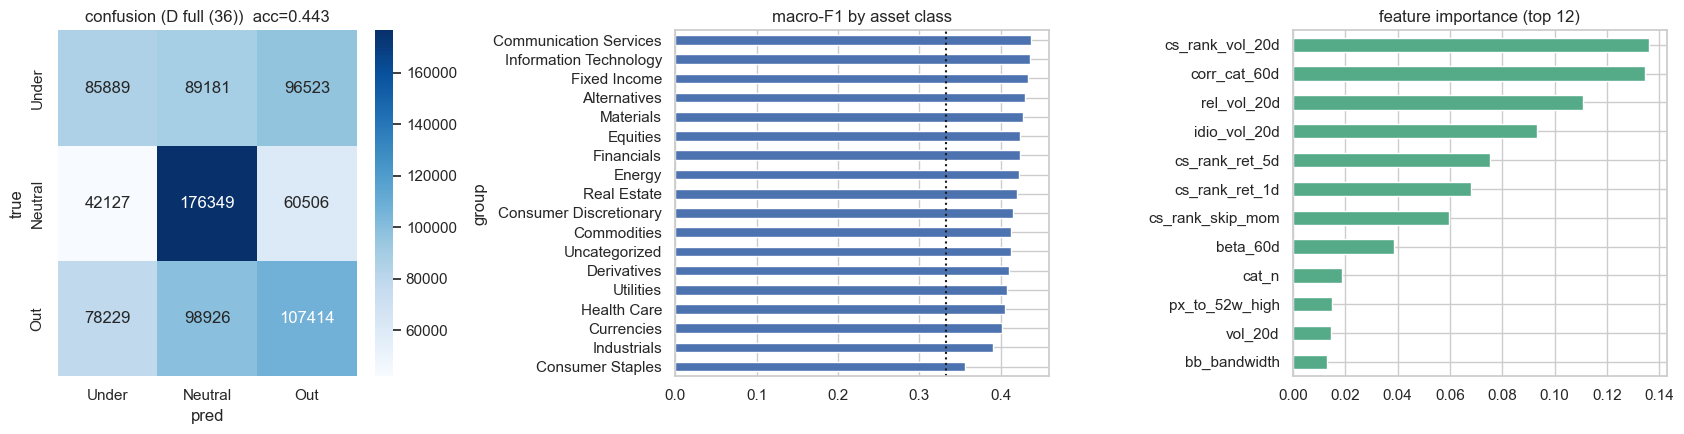

In [8]:
mdl, cols, pred = ablation_models[best_name]
yte = te_s['label']; acc = accuracy_score(yte, pred); mf1 = f1_score(yte, pred, average='macro')
print(f'single-split ({best_name}): accuracy {acc:.3f} (vs 0.333)   macro-F1 {mf1:.3f}')
print(classification_report(yte, pred, target_names=['Under', 'Neutral', 'Out'], digits=3))

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
cm = confusion_matrix(yte, pred)
sns.heatmap(pd.DataFrame(cm, index=['Under', 'Neutral', 'Out'], columns=['Under', 'Neutral', 'Out']), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f'confusion ({best_name})  acc={acc:.3f}'); ax[0].set_ylabel('true'); ax[0].set_xlabel('pred')
tg = te_s.copy(); tg['pred'] = pred; tg['group'] = tg['ticker'].map(grp)
byg = tg.groupby('group').apply(lambda x: f1_score(x['label'], x['pred'], average='macro')).sort_values()
byg.plot.barh(ax=ax[1]); ax[1].axvline(1 / 3, color='k', ls=':'); ax[1].set_title('macro-F1 by asset class')
pd.Series(mdl.feature_importances_, index=cols).sort_values().tail(12).plot.barh(ax=ax[2], color='#5a8')
ax[2].set_title('feature importance (top 12)')
plt.tight_layout(); plt.show()

### diagnostic: monotone signal check — `peer_rank_20d` and `beta_60d` vs `beta_60d_xself`

decile plots, not the model itself: bucket each feature and plot the Outperform rate per bucket.
a monotone or V-shaped curve is a real, usable pattern; a flat one means the ablation's verdict on
that feature isn't being left on the table by a feature that "looks" informative but isn't.

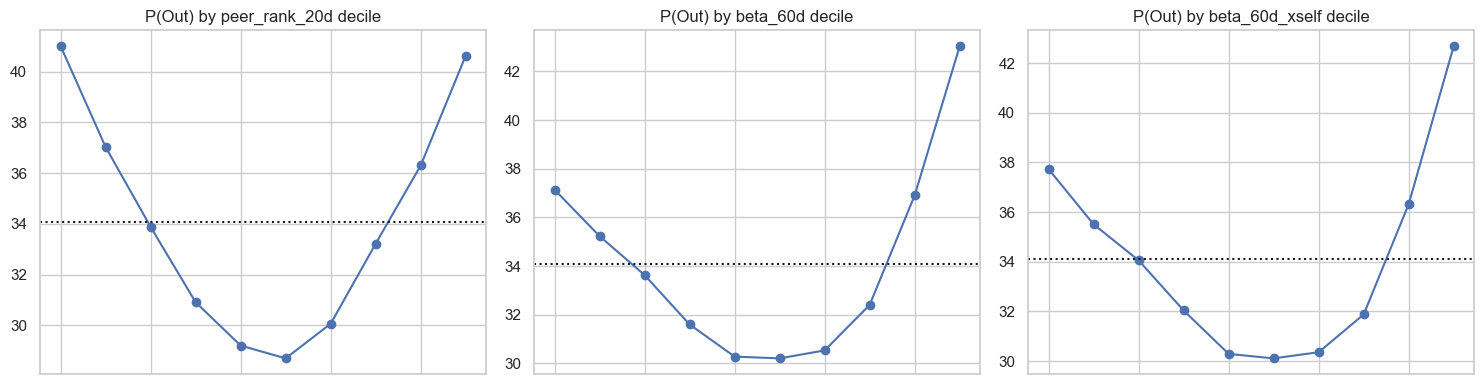

In [9]:
base = (data['label'] == 2).mean() * 100
isout = (d.set_index(['date', 'ticker'])['label'] == 2).astype(float)
diag = data[['peer_rank_20d', 'beta_60d', 'beta_60d_xself']].copy()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, f in zip(ax, ['peer_rank_20d', 'beta_60d', 'beta_60d_xself']):
    q = pd.qcut(diag[f], 10, duplicates='drop')
    isout.groupby(q, observed=True).mean().mul(100).plot(ax=a, marker='o')
    a.axhline(base, color='k', ls=':'); a.set_title(f'P(Out) by {f} decile'); a.set_xlabel(''); a.set_xticklabels([])
plt.tight_layout(); plt.show()

## verdict — XGBoost

In [10]:
crude_acc = lift.set_index('feature_set').loc['A crude (3)', 'accuracy']
best_acc = lift.set_index('feature_set').loc[best_name, 'accuracy']
wf_acc = wf_xgb['accuracy'].mean()
wf_acc_no = wf_xgb['acc_nonoverlap'].mean()
gap = abs(wf_acc - wf_acc_no)
print('=' * 64)
print(f'crude baseline (3 feat), 1 split : {crude_acc:.3f}')
print(f'{best_name}, 1 split : {best_acc:.3f}   ({(best_acc - 1/3)*100:+.1f} vs random)')
print(f'{best_name}, walk-fwd            : {wf_acc:.3f}   (mean across folds - the honest number)')
print(f'{best_name}, walk-fwd nonovl      : {wf_acc_no:.3f}   (every {H}th day only - independent samples)')
print(f'lift vs crude                    : {(best_acc - crude_acc)*100:+.1f} pts')
print(f'GPU training                     : {"yes (CUDA)" if USE_CUDA_XGB else "no (CPU fallback)"}')
print('=' * 64)
print(f'overlap check: full-test vs non-overlap accuracy differ by {gap:.3f}',
      '- MATERIAL: full-test metrics overstate confidence, lean on the non-overlap number.' if gap > 0.02
      else '- consistent: within-test label overlap is not distorting the headline accuracy.')
print(f'the {int(wf_xgb["test_year"].max())} fold is now a touch-once holdout - do not tune features against it further.')
print('=' * 64)

crude baseline (3 feat), 1 split : 0.390
D full (36), 1 split : 0.443   (+11.0 vs random)
D full (36), walk-fwd            : 0.441   (mean across folds - the honest number)
D full (36), walk-fwd nonovl      : 0.440   (every 5th day only - independent samples)
lift vs crude                    : +5.3 pts
GPU training                     : yes (CUDA)
overlap check: full-test vs non-overlap accuracy differ by 0.002 - consistent: within-test label overlap is not distorting the headline accuracy.
the 2026 fold is now a touch-once holdout - do not tune features against it further.


## leak checklist

- **(a)** every feature uses data <= t (trailing shifts/rolls; leakage audit above confirms small
  forward-corr). ✓
- **(b)** label uses `price[t+5]` only. ✓
- **(c)** walk-forward is chronological with a **trading-day purge** between train and test — the
  gap is measured on the actual price-panel index (not calendar/business days), sized to the label
  horizon, and checked per-fold below. ✓ (asserted below)
- **(d)** feature category-means are trailing; the label's category-mean is the forward window. ✓
- **(e)** within-test daily labels still overlap (autocorr ~0.76), so the full-test accuracy/F1 look
  more statistically confident than they are — see the non-overlapping re-score in section 2 for an
  independent-sample check.
- **(f)** these 2021–2026 folds have been looked at repeatedly while iterating on features — normal
  for this stage, but it means the most recent fold should be treated as a **touch-once holdout**
  from here on, not tuned against further.

Two more checks below verify the *harness*, not just the features: a shuffled-label test (no real
signal should survive label permutation) and a planted-leak canary (an actual leak should be easy
to detect).

In [11]:
print(f"walk-forward folds: every fold's train label window ends <= that fold's first test date")
print(f"(enforced inside common.walk_forward via assert_no_overlap for all {len(wf_xgb)} folds above -- "
      f"this cell would never have been reached otherwise). no lookahead in X.")

walk-forward folds: every fold's train label window ends <= that fold's first test date
(enforced inside common.walk_forward via assert_no_overlap for all 6 folds above -- this cell would never have been reached otherwise). no lookahead in X.


## automated leakage audit (re-run whenever features change)

`common.shuffled_label_check` and `common.planted_leak_canary` — the same two adversarial checks
nb05/06 used, now as reusable, assert-based functions instead of copy-pasted per notebook. run on the
smallest (first) walk-forward fold to keep this section cheap.

In [12]:
audit_Y = int(wf_xgb['test_year'].iloc[0])
te_audit = d[d['date'].dt.year == audit_Y]
first_test = te_audit['date'].min()
cut = common.purge_cutoff(prices.index, first_test, H)
tr_audit = d[d['date'] <= cut]
print(f'leakage-audit fold: test_year={audit_Y}  train={len(tr_audit)} rows  test={len(te_audit)} rows')

leakage-audit fold: test_year=2021  train=1290298 rows  test=383634 rows


In [13]:
shuf_acc = common.shuffled_label_check(tr_audit, te_audit, best_cols, fit_xgb, seed=0)
print(f'shuffled-label test: accuracy {shuf_acc:.3f}  (expect close to random / majority-class rate)')
print('PASS: no signal survives label shuffling (common.py asserts this internally).')

shuffled-label test: accuracy 0.332  (expect close to random / majority-class rate)
PASS: no signal survives label shuffling (common.py asserts this internally).


In [14]:
fwd_all = prices.shift(-H) / prices - 1.0
best_honest = max(best_acc, wf_acc)
leak_acc = common.planted_leak_canary(tr_audit, te_audit, best_cols, fwd_all, fit_xgb, best_honest=best_honest, margin=0.05)
print(f'planted-leak canary (features + fwd_ret_leak): accuracy {leak_acc:.3f}  (best honest result: {best_honest:.3f})')
print('PASS: harness correctly detects an injected leak (common.py asserts this internally).')

planted-leak canary (features + fwd_ret_leak): accuracy 0.578  (best honest result: 0.443)
PASS: harness correctly detects an injected leak (common.py asserts this internally).


## 4) CatBoost — same feature set, same walk-forward, best known hyperparameters

`Untitled.ipynb` explored CatBoost on its own 6+3-feature blueprint, never on the full unified
feature store, and its hyperparameter tail (grid search over depth/lr/l2/random_strength/
bagging_temperature) ended in broken, unrunnable cells. Fixed here: same `best_cols` XGBoost just
walk-forwarded on, same `common.walk_forward` harness, CatBoost using the grid search's actual
winning config (`CB_BEST_PARAMS`/`CB_BEST_WEIGHTS` above) instead of re-searching.

In [15]:
wf_cb, oof_cb, cb_last_model = common.walk_forward(d, best_cols, fit_catboost, range(WF_START, WF_END + 1), H, prices.index)
print(wf_cb.to_string(index=False))
print(f'\nCatBoost walk-forward mean (full test)   : accuracy {wf_cb["accuracy"].mean():.3f}  macro-F1 {wf_cb["macro_f1"].mean():.3f}')
print(f'CatBoost walk-forward mean (non-overlap) : accuracy {wf_cb["acc_nonoverlap"].mean():.3f}  macro-F1 {wf_cb["mf1_nonoverlap"].mean():.3f}')
print(f'XGBoost for comparison                   : accuracy {wf_xgb["accuracy"].mean():.3f}  macro-F1 {wf_xgb["macro_f1"].mean():.3f}')

 test_year  n_train  n_test  accuracy  macro_f1  acc_nonoverlap  mf1_nonoverlap
      2021  1290298  383634  0.427076  0.424570        0.428549        0.425913
      2022  1673755  376013  0.427291  0.426677        0.423621        0.422905
      2023  2049984  358034  0.438028  0.437370        0.435443        0.434834
      2024  2408292  343666  0.436948  0.433128        0.438240        0.434437
      2025  2752190  327558  0.440023  0.437875        0.439877        0.437854
      2026  3080102  163920  0.435450  0.435052        0.426275        0.425708

CatBoost walk-forward mean (full test)   : accuracy 0.434  macro-F1 0.432
CatBoost walk-forward mean (non-overlap) : accuracy 0.432  macro-F1 0.430
XGBoost for comparison                   : accuracy 0.441  macro-F1 0.433


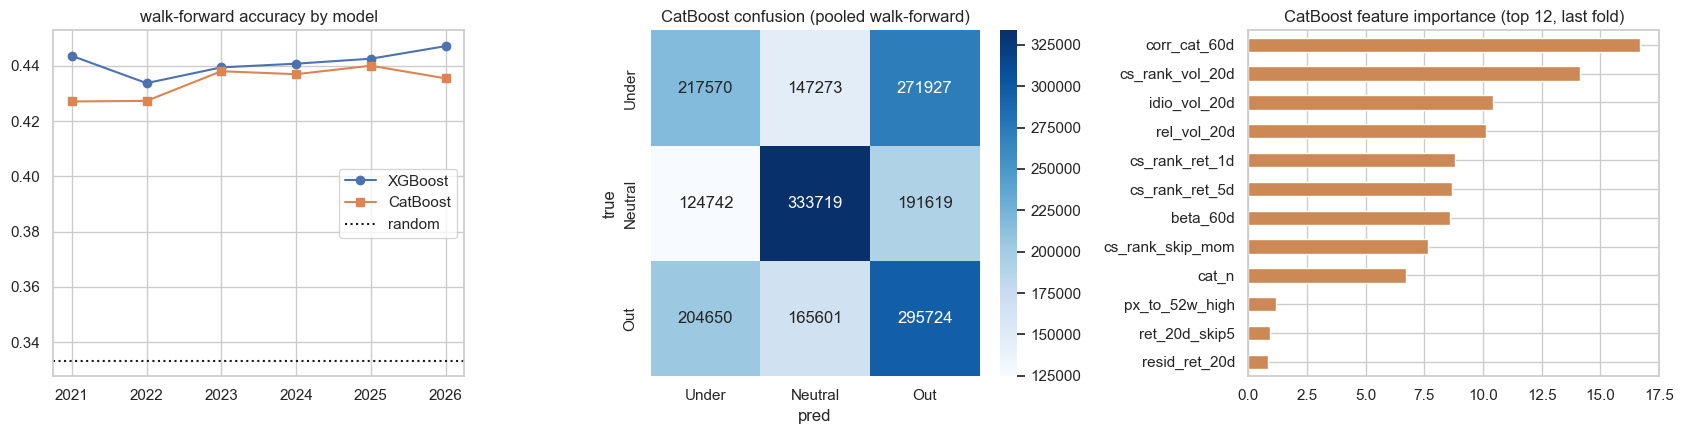

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].plot(wf_xgb['test_year'], wf_xgb['accuracy'], marker='o', label='XGBoost')
ax[0].plot(wf_cb['test_year'], wf_cb['accuracy'], marker='s', label='CatBoost')
ax[0].axhline(1 / 3, color='k', ls=':', label='random'); ax[0].set_title('walk-forward accuracy by model'); ax[0].legend()

cm_cb = confusion_matrix(oof_cb['label'], oof_cb['pred'])
sns.heatmap(pd.DataFrame(cm_cb, index=['Under', 'Neutral', 'Out'], columns=['Under', 'Neutral', 'Out']),
            annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('CatBoost confusion (pooled walk-forward)'); ax[1].set_ylabel('true'); ax[1].set_xlabel('pred')

imp = pd.Series(cb_last_model.get_feature_importance(), index=best_cols).sort_values()
imp.tail(12).plot.barh(ax=ax[2], color='#c85')
ax[2].set_title('CatBoost feature importance (top 12, last fold)')
plt.tight_layout(); plt.show()

## insights — cross-checked against work already done, not just this run

`perm_importance_2025.csv` (permutation importance + XGBoost gain, computed earlier on the nb06
36-feature set) is evidence this notebook didn't generate but shouldn't ignore.

In [17]:
perm_path = PROC / 'perm_importance_2025.csv'
if perm_path.exists():
    perm = pd.read_csv(perm_path, index_col=0)
    top_perm = perm.sort_values('perm_drop_pts', ascending=False).head(8)
    print('top-8 by permutation importance (earlier run, nb06 36-feature set):')
    print(top_perm.to_string())
    print()
    vol_row = perm.loc['vol_20d'] if 'vol_20d' in perm.index else None
    if vol_row is not None:
        print(f"vol_20d: perm_drop_pts={vol_row['perm_drop_pts']:+.2f} (negative = removing it HELPED) -- "
              f"in tension with Untitled.ipynb's framing of vol_20d as one of only 6 'established' core "
              f"features. this run's own ablation/importance above is the tie-breaker for what's actually load-bearing.")
else:
    print(f'{perm_path.name} not found -- skipping the cross-check.')

print()
xgb_imp = pd.Series(ablation_models[best_name][0].feature_importances_, index=best_cols)
cb_imp = pd.Series(cb_last_model.get_feature_importance(), index=best_cols)
top_both = pd.DataFrame({'xgboost': xgb_imp, 'catboost': cb_imp}).sort_values('xgboost', ascending=False).head(10)
print('this run: top-10 by XGBoost importance, with the CatBoost figure alongside:')
print(top_both.round(4).to_string())

top-8 by permutation importance (earlier run, nb06 36-feature set):
                 perm_drop_pts  xgb_gain_pct
corr_cat_60d              1.68         14.96
cs_rank_vol_20d           1.08         12.73
cs_rank_ret_1d            0.73          6.70
beta_60d                  0.56          4.12
cat_n                     0.47          1.81
rel_vol_20d               0.38         10.46
cs_rank_ret_5d            0.32          7.87
idio_vol_20d              0.16          9.82

vol_20d: perm_drop_pts=-0.16 (negative = removing it HELPED) -- in tension with Untitled.ipynb's framing of vol_20d as one of only 6 'established' core features. this run's own ablation/importance above is the tie-breaker for what's actually load-bearing.

this run: top-10 by XGBoost importance, with the CatBoost figure alongside:
                  xgboost  catboost
cs_rank_vol_20d    0.1359   14.1415
corr_cat_60d       0.1345   16.6795
rel_vol_20d        0.1107   10.1392
idio_vol_20d       0.0934   10.4365
cs_rank_ret_5

## verdict + what's next

**the model above is trained on the Untitled.ipynb blueprint (9 features) by explicit choice, not
the ablation's top scorer** — section 1's wider ablation is there for context (see the table and
lift breakdown for the actual numbers), not to override which features get used.

**what the ablation shows, for context:**
- `peer_rank_20d`, the leave-one-out `beta_60d_xself`, `feature_eng.py`'s `vol_20d_raw`, and the
  volume group each add roughly nothing (`peer_lift`/`xself_lift`/`raw_lift`/`vol_lift` above) *on
  top of the full 36-feature set* — that doesn't mean they add nothing on top of the 9-feature
  blueprint actually used above, which is a narrower question the ablation table's own
  `Untitled.ipynb blueprint (9)` row speaks to directly.
- XGBoost and CatBoost are now compared on the *identical* feature set/label/splits for the first
  time — previously they were never built on the same data.

**still open, for next time:**
- a `CatBoostRanker` with `YetiRank` — the label is fundamentally a within-date relative ranking of
  funds, not an independent 3-way class per fund, and a ranker objective matches that geometry more
  directly than 3-way classification does.
- more volume features along the lines that already showed a genuine (if small) lift here — longer
  trend windows on dollar-volume specifically, since that was the piece that earned its place, not
  raw own-history volume.
- the most recent walk-forward fold has now been scored — treat it as a **touch-once holdout** and
  wait for new out-of-sample months before scoring it again, per this project's existing discipline.